<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> AI For Leaders - 2 <br>
<b>Semester:</b> Spring 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

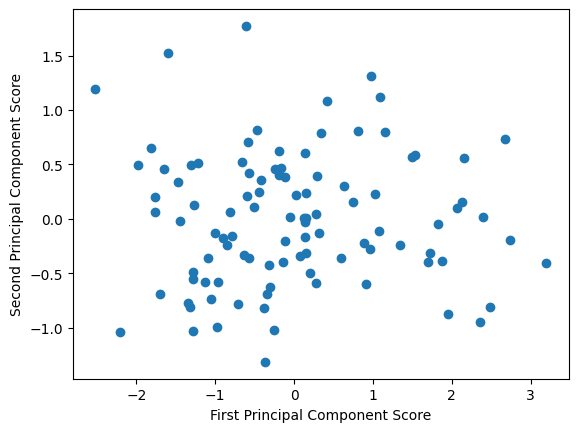

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

**Answer**

| Principal Component | Variance Explained | series_1 | series_2 | series_3 | Interpretation                                                |
| ------------------- | ------------------ | -------- | -------- | -------- | ------------------------------------------------------------- |
| **PC1**             | 0.7992 (~80%)      | 0.2654   | 0.3010   | 0.9160   | Dominated by **series_3**                                     |
| **PC2**             | 0.1899 (~19%)      | 0.6034   | 0.6891   | -0.4013  | Contrast between (**series_1**, **series_2**) vs **series_3** |
| **PC3**             | 0.0109 (~1%)       | 0.7520   | -0.6592  | -0.0013  | Difference between **series_1** and **series_2**              |


**Outliers in the Upper-Left Corner**: </br>
The three points in the upper-left corner of the scatter plot have:
- Low PC1 scores (because they are on the left side)
- High PC2 scores (because they are toward the top) 

Since PC1 is dominated by series_3, a low PC1 score indicates that these observations have low values in series_3.

At the same time, PC2 represents a contrast between (series_1, series_2) and series_3, with positive contributions from series_1 and series_2, and a negative contribution from series_3. </br>Therefore, a high PC2 score means that series_1 and/or series_2 are relatively high compared to series_3.

- <u>Conclusion</u></br>
These outliers correspond to observations where:
    - series_3 is unusually **low**
    - series_1 and series_2 are **relatively higher**

**Why It Is Easier to Interpret series_3 Than series_1 and series_2**: </br>
It is easier to make conclusions about series_3 because it has much **higher variability** than the other two series. Specifically:
- series_3 was generated with larger noise **(scale = 0.5)**
- series_1 and series_2 have much **smaller variation**:
    - series_1 is generated from a <u>normal distribution with moderate variance (scale = 0.5)</u>
    - series_2 is created as: <u>series_2 = series_1 * (1 + small noise) where the noise has a small scale (0.1)</u>

- <u>As a result:</u>
    - series_3 **dominates the variance** in the dataset
    - PCA prioritizes directions with the most variance, so **PC1 is largely driven by series_3**

**Relationship Between series_1 and series_2 :** 

series_2 was created directly from series_1: **series_2 = series_1 * (1 + small noise)**

- <u>This means:</u>
    - series_2 is essentially a **scaled version of series_1 with small noise**
    - The two variables are **highly correlated (almost linearly dependent)**

**Why It Is Difficult to Distinguish series_1 and series_2:**

Because series_1 and series_2 are so **strongly correlated**:
- PCA treats them as **one combined direction**
- Their **differences are very small**, contributing only about **1% of total variance (PC3)**

- <u>Implications</u>
    - It is **difficult to determine their individual values** from the PCA plot
    - It is **almost impossible to determine which one is larger** for a given point
    - Their relationship is essentially **redundant**

<Figure size 640x480 with 0 Axes>

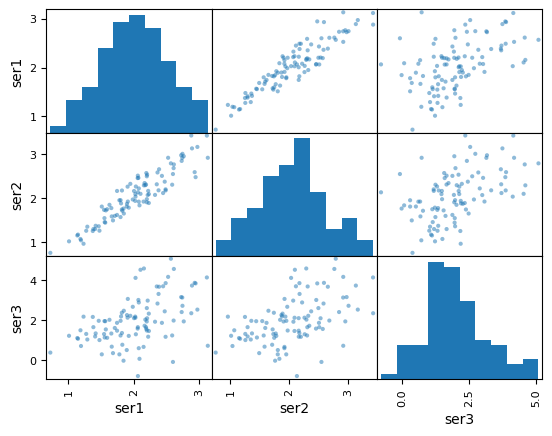

In [2]:
from pandas.plotting import scatter_matrix

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc=2, scale=0.5, size=num_points)
series_2 = series_1 * (1 + np.random.normal(loc=0, scale=0.1, size=num_points))
series_3 = series_1 * (1 + np.random.normal(loc=0, scale=0.5, size=num_points))

df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})

# Create pairplot (scatter matrix)
plt.figure()
scatter_matrix(df, diagonal='hist')
plt.show()

**Pairplot of the Three Series**

- Observations from the Pairplot
    - series_1 vs series_2: nearly a **perfect straight line** → very strong correlation
    - series_3 vs others: **more spread** → higher variability
    - Histograms show series_3 has a **wider distribution**

**Advantages of the PCA Scatter Plot**
- **Dimensionality reduction**: simplifies 3 variables into 2 dimensions while preserving ~99% of variance
- **Clear visualization of structure**: shows dominant direction of variation (PC1)
- **Outlier detection**: unusual points (like the upper-left ones) are easy to identify
- **Reveals redundancy**: shows that series_1 and series_2 behave similarly


**Disadvantages of the PCA Scatter Plot**
- **Loss of interpretability**: axes are combinations of variables, not the original features
- **Cannot distinguish correlated variables**: series_1 and series_2 appear merged
- **Information loss**: small but meaningful variation (PC3) is not shown
- **Hard to interpret exact values** of original variables


**Overall Assessment** </br>
The graph does show meaningful structure:
- It reveals that the data is largely **one-dimensional**, driven by series_3
- It highlights the **redundancy** between series_1 and series_2
- It identifies **outliers related to unusual values in series_3**

However, it also demonstrates a **limitation** of PCA:
- When variables are highly correlated, PCA compresses them into a single direction, making it difficult to analyze them individually.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
# Packages 
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load Preprocessed Dataset*

In [4]:
dataset_path = "data/dataset1_diabetes_preprocessed_week2.csv"
df_diabetes = pd.read_csv(dataset_path)

# drop index-like column
df_diabetes = df_diabetes.drop(columns=["Unnamed: 0"])

#### [Dataset 1] | *2- Heatmap 1: Diabetes by Age and General Health*

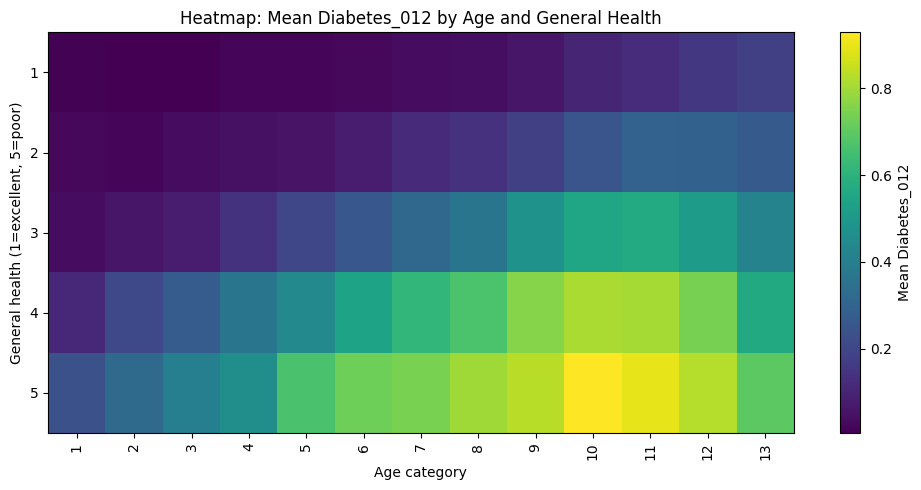

In [5]:

heat1 = df_diabetes.pivot_table(
    index="GenHlth",
    columns="Age",
    values="Diabetes_012",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
plt.imshow(heat1, aspect="auto")
plt.colorbar(label="Mean Diabetes_012")
plt.xticks(range(len(heat1.columns)), [int(c) for c in heat1.columns], rotation=90)
plt.yticks(range(len(heat1.index)), [int(i) for i in heat1.index])
plt.xlabel("Age category")
plt.ylabel("General health (1=excellent, 5=poor)")
plt.title("Heatmap: Mean Diabetes_012 by Age and General Health")
plt.tight_layout()
plt.show()

In [6]:
# display the values of each cell in the heatmap above
heat1

Age,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0
GenHlth,,,,,,,,,,,,,
1.0,0.010211,0.007626,0.005952,0.018995,0.018658,0.025766,0.035423,0.039367,0.060321,0.100000,0.124252,0.156833,0.179363
2.0,0.024180,0.019967,0.035139,0.045912,0.053657,0.076006,0.118871,0.137407,0.181754,0.248410,0.295850,0.292067,0.267843
3.0,0.036642,0.063221,0.079545,0.141259,0.202443,0.254871,0.313968,0.365076,0.478603,0.550072,0.569315,0.512793,0.417711
4.0,0.107438,0.210000,0.273854,0.365179,0.439893,0.541176,0.616883,0.665673,0.759413,0.812809,0.804527,0.738604,0.566909
5.0,0.235294,0.325301,0.404762,0.461538,0.665138,0.726064,0.744251,0.796020,0.828601,0.928702,0.893634,0.824795,0.695893


**Results**

A few useful summary values:
- Lowest cell mean: about **0.006**
- Highest cell mean: about **0.929**
- **Diabetes** risk clearly **increases** as:
    - *Age category* <u>increases</u>
    - *General health* <u>worsens</u>

Examples from the data:
- GenHlth = 1 has low diabetes levels overall
- GenHlth = 5 has much higher diabetes levels
- Older age groups show much higher averages than younger groups


**Interpretation**

This is one of the clearest patterns in the dataset: 
- Poorer general health and older age are strongly associated with more diabetes. This makes sense medically and is what I would expect from real-world health data.


**Discussion**

This heatmap is useful because it shows interaction between two variables at once:
- Age alone matters, and general health alone matters, but together they show an even clearer gradient.


**Conclusion**

This heatmap supports the idea that the data are meaningful and internally consistent. It also suggests that **Age** and **GenHlth** are likely **useful features for prediction**.

#### [Dataset 1] | *3- Heatmap 2: Diabetes by Income and Education*

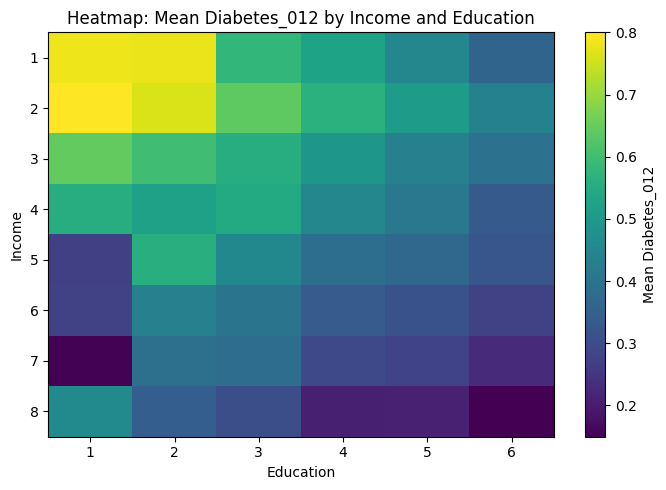

In [7]:
heat2 = df_diabetes.pivot_table(
    index="Income",
    columns="Education",
    values="Diabetes_012",
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))
plt.imshow(heat2, aspect="auto")
plt.colorbar(label="Mean Diabetes_012")
plt.xticks(range(len(heat2.columns)), [int(c) for c in heat2.columns])
plt.yticks(range(len(heat2.index)), [int(i) for i in heat2.index])
plt.xlabel("Education")
plt.ylabel("Income")
plt.title("Heatmap: Mean Diabetes_012 by Income and Education")
plt.tight_layout()
plt.show()

In [8]:
# display the values of each cell in the heatmap above
heat2

Education,1.0,2.0,3.0,4.0,5.0,6.0
Income,,,,,,
1.0,0.783784,0.781111,0.580078,0.526433,0.450144,0.358072
2.0,0.800000,0.762483,0.638908,0.565857,0.506486,0.435599
3.0,0.642857,0.600000,0.555881,0.493780,0.431818,0.391119
4.0,0.555556,0.522314,0.548520,0.449994,0.409826,0.334677
5.0,0.272727,0.558577,0.452681,0.385806,0.367992,0.323729
6.0,0.277778,0.433447,0.400651,0.336737,0.312354,0.276556
7.0,0.153846,0.388889,0.381356,0.292773,0.280269,0.227549
8.0,0.461538,0.345070,0.305970,0.207057,0.209080,0.149735


**Results**

Overall trend:
- Diabetes tends to be **higher at lower income levels**
- Diabetes tends to be **lower at higher education levels**


**Interpretation**

<u>Socioeconomic</u> variables appear related to diabetes burden. Lower income and lower education are associated with higher diabetes levels.


**Conclusion**

Income and education look informative, especially as broader risk indicators rather than direct medical causes.

#### [Dataset 1] | *4- Bubble Plot : Age, BMI Category, and Diabetes Rate*

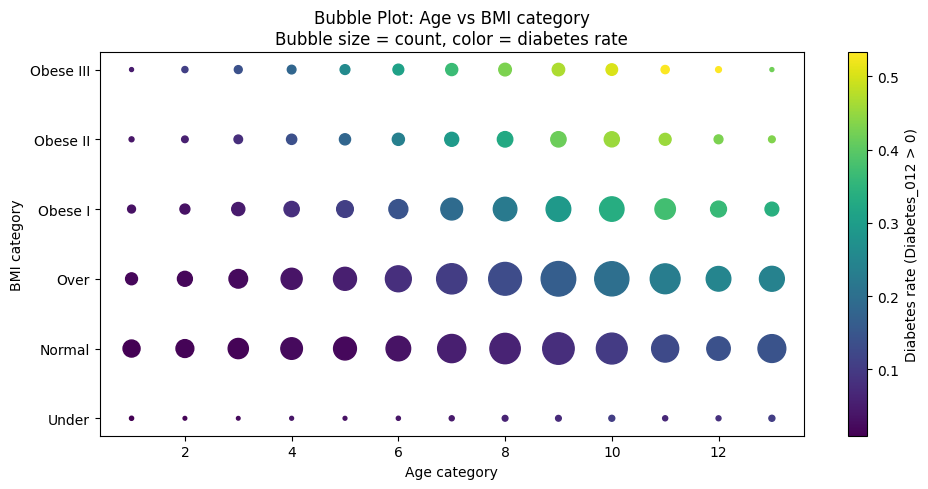

In [9]:
df_diabetes["Diabetes_any"] = (df_diabetes["Diabetes_012"] > 0).astype(int)

df_diabetes["BMI_bin"] = pd.cut(
    df_diabetes["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, 100],
    labels=["Under", "Normal", "Over", "Obese I", "Obese II", "Obese III"]
)

bubble = df_diabetes.groupby(["Age", "BMI_bin"], observed=False).agg(
    diabetes_rate=("Diabetes_any", "mean"),
    count=("Diabetes_any", "size"),
    mean_genhlth=("GenHlth", "mean")
).reset_index()

ypos = {lab: i for i, lab in enumerate(bubble["BMI_bin"].cat.categories)}

plt.figure(figsize=(10, 5))
plt.scatter(
    bubble["Age"],
    bubble["BMI_bin"].map(ypos),
    s=bubble["count"] / 20,
    c=bubble["diabetes_rate"]
)
plt.colorbar(label="Diabetes rate (Diabetes_012 > 0)")
plt.yticks(list(ypos.values()), list(ypos.keys()))
plt.xlabel("Age category")
plt.ylabel("BMI category")
plt.title("Bubble Plot: Age vs BMI category\nBubble size = count, color = diabetes rate")
plt.tight_layout()
plt.show()

**Results**

Highest diabetes rates appear in:
- **older age** groups
- **higher BMI** categories, especially <u>Obese II and Obese III</u>

Examples from the aggregated results:
- Some of the largest diabetes rates are above **0.50** in **older + Obese III** groups
- **Younger + normal-weight** groups are much lower, often close to 0.01 - 0.05


**Interpretation**

The bubble plot shows that both **age** and **BMI** are <u>strongly associated with diabetes</u>. The pattern is gradual rather than random.


**Conclusion**

BMI and age are both <u>very important features</u>, and their combination is especially informative.

#### [Dataset 1] | *5- Correlation Analysis*

In [10]:
corr = df_diabetes.drop(columns=["BMI_bin"]).corr(numeric_only=True)
target_corr = corr["Diabetes_012"].sort_values(key=lambda s: s.abs(), ascending=False)

print(target_corr)

Diabetes_012            1.000000
Diabetes_any            0.983304
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Income                 -0.171483
Education              -0.130517
PhysActivity           -0.121947
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
Veggies                -0.058972
HvyAlcoholConsump      -0.057882
Fruits                 -0.042192
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Name: Diabetes_012, dtype: float64


**Results**

Strongest correlations with **Diabetes_012**:

| Feature              | Correlation with Diabetes_012 |
| -------------------- | ----------------------------: |
| GenHlth              |                        0.3026 |
| HighBP               |                        0.2716 |
| BMI                  |                        0.2244 |
| DiffWalk             |                        0.2242 |
| HighChol             |                        0.2091 |
| Age                  |                        0.1850 |
| HeartDiseaseorAttack |                        0.1803 |
| PhysHlth             |                        0.1763 |
| Income               |                       -0.1715 |
| Education            |                       -0.1305 |
| PhysActivity         |                       -0.1219 |


**Interpretation**

The strongest relationships are reasonable:
- worse general health
- high blood pressure
- higher BMI
- difficulty walking
- older age
- poorer physical health

Negative correlations with income, education, and physical activity also make sense.


**Discussion**

These correlations are <u>not extremely large</u>, but that is normal in health data. Diabetes is influenced by many factors, so <u>moderate correlations can still be useful</u>.


**Conclusion**

This gives a good starting point for feature selection in regression.

#### [Dataset 1] | *6- Principal Component Analysis (PCA)*

#### <u>**PCA on Predictor Variables**</u>

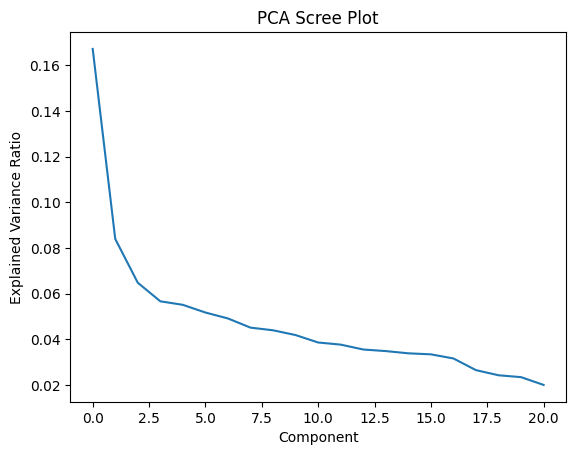

Explained variance by first 10 components:
[0.16713006 0.08396704 0.06480288 0.05667649 0.05512874 0.05176754
 0.04916833 0.04515407 0.04399236 0.04190459]
------------------------------------------------------
------------------------------------------------------
Cumulative variance of 10 first components:
[0.16713006 0.2510971  0.31589998 0.37257647 0.42770521 0.47947275
 0.52864108 0.57379515 0.61778751 0.6596921 ]


In [11]:
X = df_diabetes.drop(columns=["Diabetes_012", "Diabetes_any", "BMI_bin"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum = explained.cumsum()

plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Scree Plot")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

print('Explained variance by first 10 components:')
print(explained[:10])
print('------------------------------------------------------')
print('------------------------------------------------------')
print('Cumulative variance of 10 first components:')
print(cum[:10])

**Results**

Explained variance by first components:

- PC1 = 0.1671 → 16.7%
- PC2 = 0.0840 → 8.4%
- PC3 = 0.0648 → 6.5%

Cumulative variance:

- first 1 PC = 16.7%
- first 2 PCs = 25.1%
- first 7 PCs = 52.9%
- first 14 PCs = 80.0%
- first 17 PCs = 90.0%

**Interpretation**

This dataset is **not close to one-dimensional**. The first principal component captures only **16.7%** of the variance, which is <u>not enough to represent the full dataset well on its own.</u>


**Discussion**

This means the diabetes data vary in several different directions at once. There is no single dominant underlying factor that explains most of the dataset.


**Conclusion**

You **cannot represent this dataset well using only the first principal component**. Using one or two PC scores <u>would lose too much information.</u>

#### <u>**What Does PC1 Represent?**</u>

In [12]:
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)
pc1_loadings = pc1_loadings.sort_values(key=lambda s: s.abs(), ascending=False)
print(pc1_loadings)

GenHlth                 0.405406
DiffWalk                0.358398
PhysHlth                0.343743
Income                 -0.320321
Education              -0.258411
HighBP                  0.256439
PhysActivity           -0.237259
MentHlth                0.223139
HeartDiseaseorAttack    0.218694
HighChol                0.191361
Age                     0.174311
BMI                     0.173618
Stroke                  0.168297
Smoker                  0.154896
NoDocbcCost             0.136954
Veggies                -0.129681
Fruits                 -0.101841
AnyHealthcare          -0.044731
CholCheck               0.038535
HvyAlcoholConsump      -0.027288
Sex                    -0.018603
dtype: float64


**Results**

Largest absolute loadings in PC1:

| Feature              | PC1 loading |
| -------------------- | ----------: |
| GenHlth              |      0.4054 |
| DiffWalk             |      0.3584 |
| PhysHlth             |      0.3437 |
| Income               |     -0.3203 |
| Education            |     -0.2584 |
| HighBP               |      0.2564 |
| PhysActivity         |     -0.2373 |
| MentHlth             |      0.2231 |
| HeartDiseaseorAttack |      0.2187 |
| HighChol             |      0.1914 |


**Interpretation**

PC1 looks like a **general overall health burden / disadvantage** direction:
- worse health variables load positively
- income, education, and physical activity load negatively


**Conclusion**

PC1 is meaningful, but it is not strong enough by itself to summarize the whole dataset.

#### <u>**PCA Scatter Plot**</u>

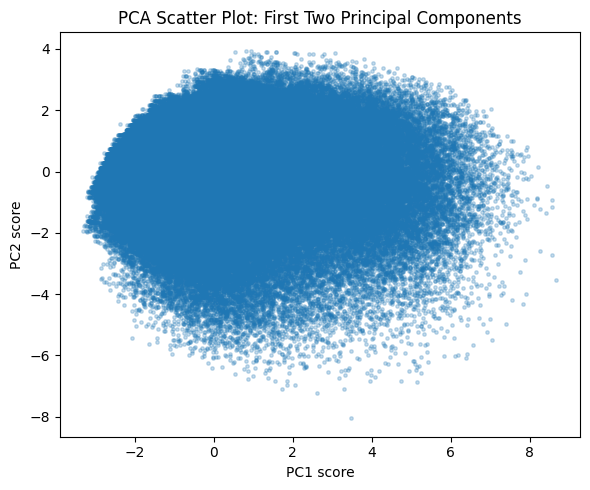

In [13]:
scores = pca.transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(scores[:, 0], scores[:, 1], s=6, alpha=0.25)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("PCA Scatter Plot: First Two Principal Components")
plt.tight_layout()
plt.show()

**Interpretation**

The PCA scatter does not collapse into a narrow line or very tight low-dimensional shape. That supports the conclusion that <u>the data require multiple dimensions.</u>

#### [Dataset 1] | *7- Can the Data Be Represented with Fewer Dimensions?*

**Answer**

Only to a limited extent:
- First principal component alone captures **16.7%**
- First two components capture **25.1%**


**Interpretation**

That is too little for a strong low-dimensional representation. The dataset contains several partially independent kinds of variation:
- physical health burden
- socioeconomic status
- age-related risk
- behavior / access variables


**Conclusion**

The dataset does **not** compress well into one or two dimensions. PCA is still useful for understanding structure, but not for replacing the original variables with just one or two scores.

#### [Dataset 1] | *8- Linear Regression Analysis*

#### <u>**Regression 1 : Predicting BMI**</u>

In [14]:

features = ["GenHlth", "Age", "Income", "Education", "PhysActivity",
            "HighBP", "HighChol", "DiffWalk"]

X = df_diabetes[features]
y = df_diabetes["BMI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print('--------------------------------------------')
print("Coefs:")
print(pd.Series(model.coef_, index=features).sort_values(key=lambda s: s.abs(), ascending=False))

R^2: 0.1141669191696324
RMSE: 6.205945486992576
--------------------------------------------
Coefs:
HighBP          2.449755
DiffWalk        1.888000
PhysActivity   -1.133632
GenHlth         0.811048
HighChol        0.624416
Age            -0.346283
Education      -0.205534
Income          0.087548
dtype: float64


**Results**
- **R² = 0.1142**
- **RMSE = 6.206**


**Interpretation**

These features explain only about **11.4%** of the variance in **BMI**. That means BMI is <u>not especially well predicted</u> by this set using a simple linear model.


**Conclusion**

**BMI** appears to depend on factors not fully captured here, or the relationships may be partly nonlinear.

#### <u>**Regression 2 : Predicting General Health**</u>

In [15]:
features = ["PhysHlth", "DiffWalk", "BMI", "Age", "Income",
            "Education", "HighBP", "HeartDiseaseorAttack", "MentHlth"]

X = df_diabetes[features]
y = df_diabetes["GenHlth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print('--------------------------------------------')
print("Coefs:")
print(pd.Series(model.coef_, index=features).sort_values(key=lambda s: s.abs(), ascending=False))

R^2: 0.43447592754511133
RMSE: 0.8042222496619006
--------------------------------------------
Coefs:
DiffWalk                0.433114
HeartDiseaseorAttack    0.367702
HighBP                  0.272872
Education              -0.110546
Income                 -0.063229
PhysHlth                0.038568
BMI                     0.017325
MentHlth                0.014030
Age                     0.004078
dtype: float64


**Results**
- **R² = 0.4345**
- **RMSE = 0.8042**


**Interpretation**

This is a much stronger model. About **43.4%** of the variance in *GenHlth* is explained by the selected features.


**Discussion**

This makes sense because *GenHlth* is strongly related to:
- *PhysHlth*
- *DiffWalk*
- *BMI*
- *Age*
- *MentHlth*


**Conclusion**

*GenHlth* is one of the most predictable variables in the dataset using linear regression.

#### <u>**Regression 3 : Predicting Physical Health Days**</u>

In [16]:
features = ["GenHlth", "DiffWalk", "BMI", "Age", "Income",
            "Education", "HighBP", "HeartDiseaseorAttack", "MentHlth"]

X = df_diabetes[features]
y = df_diabetes["PhysHlth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

R^2: 0.3849936403272306
RMSE: 6.82749494803914


**Results**
- **R² = 0.3850**
- **RMSE = 6.8275**


**Interpretation**

This is also a reasonably useful model. *PhysHlth* can be <u>predicted moderately</u> well from related health variables.


**Conclusion**

**Health-status variables** predict each other better than they predict things like *BMI*.

#### <u>**Regression 4 : Predicting Diabetes_012 with Linear Regression**</u>

In [17]:
features = ["GenHlth", "HighBP", "BMI", "DiffWalk", "HighChol",
            "Age", "HeartDiseaseorAttack", "PhysHlth",
            "Income", "Education", "PhysActivity"]

X = df_diabetes[features]
y = df_diabetes["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print('--------------------------------------------')
print("Coefs:")
print(pd.Series(model.coef_, index=features).sort_values(key=lambda s: s.abs(), ascending=False))

R^2: 0.16992699277334966
RMSE: 0.6335530811586196
--------------------------------------------
Coefs:
HighBP                  0.158427
HeartDiseaseorAttack    0.151683
HighChol                0.118197
GenHlth                 0.098259
DiffWalk                0.095356
Age                     0.017154
BMI                     0.014839
Income                 -0.012098
PhysActivity           -0.011195
Education              -0.007835
PhysHlth               -0.000292
dtype: float64


**Results**
- **R² = 0.1699**
- **RMSE = 0.6336**


**Interpretation**

This model has <u>limited predictive power</u>. That is not surprising, because *Diabetes_012* is an <u>ordinal/categorical outcome</u>, and linear regression is not the ideal method for it.


**Discussion**

The model still confirms that the most useful predictors are health and risk variables such as:
- *GenHlth*
- *HighBP*
- *BMI*
- *DiffWalk*
- *Age*


**Conclusion**

Linear regression gives some signal, but for real prediction of diabetes status, a **classification model** would be better.

#### [Dataset 1] | *9- Which Features Seem Most Useful for Predicting Other Features?*

Based on the **correlations and regression results**, the most useful features appear to be:

- *GenHlth*
- *PhysHlth*
- *DiffWalk*
- *BMI*
- *Age*
- *HighBP*
- *Income*
- *Education*


**Why these features?**

Because they either:
- have **stronger correlations** with important outcomes, or
- repeatedly **appear in successful regression models**


**Best example**

The strongest general relationship in the data is between:
- *GenHlth*
- *PhysHlth*
- *DiffWalk*

These seem to capture a shared dimension of health burden.

#### [Dataset 1] | *10- Outliers*

In [18]:
cont_cols = ["BMI", "MentHlth", "PhysHlth"]
z = ((df_diabetes[cont_cols] - df_diabetes[cont_cols].mean()) / df_diabetes[cont_cols].std()).abs()
print((z > 3).sum())

print('\n\n')

print(df_diabetes.sort_values("BMI", ascending=False)[
    ["BMI", "Age", "GenHlth", "Diabetes_012", "HighBP", "DiffWalk"]
].head(10))

BMI          2963
MentHlth    12697
PhysHlth        0
dtype: int64



        BMI   Age  GenHlth  Diabetes_012  HighBP  DiffWalk
76532  98.0  13.0      2.0           0.0     1.0       0.0
79554  98.0  10.0      2.0           0.0     0.0       0.0
79507  98.0  10.0      3.0           2.0     0.0       0.0
79478  98.0  10.0      3.0           0.0     1.0       1.0
76394  98.0   8.0      5.0           2.0     1.0       1.0
76396  98.0  11.0      4.0           2.0     1.0       1.0
76370  98.0   3.0      2.0           0.0     0.0       0.0
36324  96.0   6.0      2.0           1.0     1.0       0.0
79522  95.0   7.0      5.0           0.0     1.0       1.0
79418  95.0   7.0      2.0           0.0     0.0       0.0


**Results**

Outlier-like counts using **|z| > 3**:

- *BMI*: 2,963
- *MentHlth*: 12,697
- *PhysHlth*: 0


Notable BMI extremes:
- maximum BMI values are **95–98**


**Interpretation**

There are some clear extreme *BMI* values. They may be valid, but they are far from the center of the data and could affect some analyses.</br> 
*MentHlth* also has many high-end values, but since the variable is capped at 30 days, those may reflect <u>real responses rather than data errors</u>.


**Conclusion**

Yes, the data contain outliers, especially in BMI. They <u>should be monitored</u> if building predictive models.

#### [Dataset 1] | *11- Overall Conclusions*

- The diabetes dataset is usable and informative. 
- The strongest patterns point to a broad health-risk profile: poorer health, mobility difficulty, higher BMI, older age, and lower socioeconomic status are all associated with more diabetes. 
- PCA helps reveal structure, but the data are too complex to summarize well with only one or two principal components.

## Dataset 2: Estimation of Obesity Levels Based on Eating Habits and Physical Condition

#### [Dataset 2] | *1- Load Preprocessed Dataset*

In [19]:
df_obesity = pd.read_csv("data/dataset2_obesity_preprocessed_week2_1.csv")

df_obesity = df_obesity.drop(columns=["Unnamed: 0"])

#### [Dataset 2] | *2- Heatmap 1 : Mean BMI by Age Group and Physical Activity*

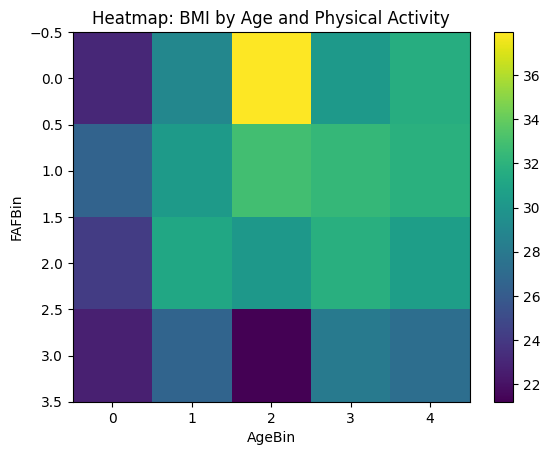

AgeBin          <=20      20-25      25-30      30-40        40+
FAFBin                                                          
Low        23.075777  28.927605  37.949935  30.219016  31.633556
Moderate   26.538821  30.357725  32.894133  32.342305  31.832591
High       24.175626  31.146116  30.153532  31.754148  30.596231
Very High  22.641972  26.619260  21.200991  28.046716  27.240000


In [20]:
# I binned Age and FAF (physical activity frequency) to create a heatmap

df_obesity["AgeBin"] = pd.cut(
    df_obesity["Age"],
    bins=[0, 20, 25, 30, 40, 100],
    labels=["<=20", "20-25", "25-30", "30-40", "40+"],
    include_lowest=True
)

df_obesity["FAFBin"] = pd.cut(
    df_obesity["FAF"],
    bins=[-0.001, 0.5, 1.5, 2.5, 3.1],
    labels=["Low", "Moderate", "High", "Very High"]
)

heat1 = df_obesity.pivot_table(
    index="FAFBin",
    columns="AgeBin",
    values="BMI",
    aggfunc="mean"
)

plt.imshow(heat1, aspect='auto')
plt.colorbar()
plt.title("Heatmap: BMI by Age and Physical Activity")
plt.xlabel("AgeBin")
plt.ylabel("FAFBin")
plt.show()

print(heat1)

In [21]:
# better display of heatmap cells values 
pd.DataFrame(heat1)

AgeBin,<=20,20-25,25-30,30-40,40+
FAFBin,,,,,
Low,23.075777,28.927605,37.949935,30.219016,31.633556
Moderate,26.538821,30.357725,32.894133,32.342305,31.832591
High,24.175626,31.146116,30.153532,31.754148,30.596231
Very High,22.641972,26.619260,21.200991,28.046716,27.240000


**Interpretation**

A few patterns stand out:

- *BMI* tends to be **higher** in **older age groups, especially 25–30**
- *BMI* tends to be **lower** when **physical activity is very high**
- The **highest** mean *BMI* appears in the **25–30 / low-activity group**


**Discussion**

This is a sensible result. People with lower physical activity tend to have higher BMI, and the relationship is strongest in some age ranges.


**Conclusion**

The data behave as expected. *Age* and *FAF* appear useful for understanding obesity patterns.

#### [Dataset 2] | *3- Heatmap 2 : Obesity Level by Eating Between Meals and Alcohol Consumption*

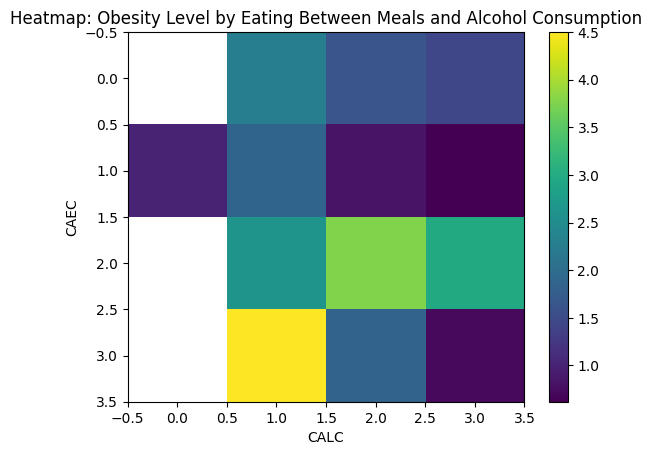

CALC        Always  Frequently  Sometimes        no
CAEC                                               
Always         NaN    2.285714   1.642857  1.444444
Frequently     1.0    1.875000   0.816667  0.619048
Sometimes      NaN    2.622222   3.767135  2.978389
no             NaN    4.500000   1.857143  0.714286


In [22]:
# I converted the obesity classes into an ordinal scale:
ob_map = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df_obesity["ObesityOrdinal"] = df_obesity["NObeyesdad"].map(ob_map)

heat2 = df_obesity.pivot_table(
    index="CAEC",
    columns="CALC",
    values="ObesityOrdinal",
    aggfunc="mean"
)

plt.imshow(heat2, aspect='auto')
plt.colorbar()
plt.title("Heatmap: Obesity Level by Eating Between Meals and Alcohol Consumption")
plt.xlabel("CALC")
plt.ylabel("CAEC")
plt.show()

print(heat2)

In [23]:
pd.DataFrame(heat2)

CALC,Always,Frequently,Sometimes,no
CAEC,,,,
Always,NaN,2.285714,1.642857,1.444444
Frequently,1.0,1.875000,0.816667,0.619048
Sometimes,NaN,2.622222,3.767135,2.978389
no,NaN,4.500000,1.857143,0.714286


**Interpretation**

This heatmap is harder to interpret because some cells are sparse and probably contain few observations.</br>
Still:
- eating between meals (*CAEC*) seems related to higher obesity levels in some groups
- some alcohol-consumption categories also vary with obesity level


**Discussion**

This graph is more exploratory than conclusive. Some extreme cells may reflect small sample sizes.

**Conclusion**

This heatmap suggests there may be interactions between eating habits and obesity, but these patterns should be interpreted with caution.

#### [Dataset 2] | *4- Bubble Plot : Age, Physical Activity, and Obesity Rate*

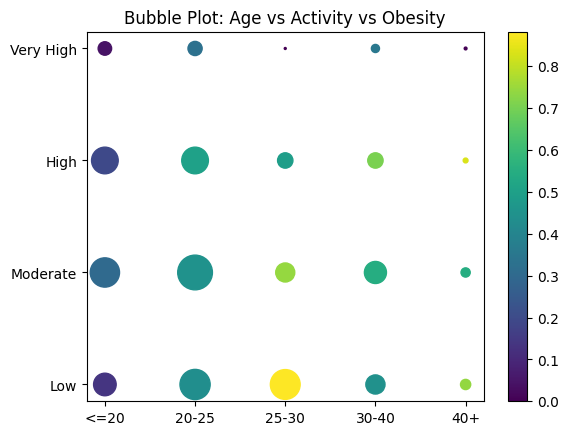

   AgeBin     FAFBin   mean_bmi  obesity_rate  count
0    <=20        Low  23.075777      0.136364    132
1    <=20   Moderate  26.538821      0.301802    222
2    <=20       High  24.175626      0.195652    184
3    <=20  Very High  22.641972      0.042553     47
4   20-25        Low  28.927605      0.432203    236
5   20-25   Moderate  30.357725      0.448718    312
6   20-25       High  31.146116      0.500000    184
7   20-25  Very High  26.619260      0.326923     52
8   25-30        Low  37.949935      0.882609    230
9   25-30   Moderate  32.894133      0.744681     94
10  25-30       High  30.153532      0.491803     61
11  25-30  Very High  21.200991      0.000000      1
12  30-40        Low  30.219016      0.442105     95
13  30-40   Moderate  32.342305      0.547619    126
14  30-40       High  31.754148      0.704918     61
15  30-40  Very High  28.046716      0.352941     17
16    40+        Low  31.633556      0.740741     27
17    40+   Moderate  31.832591      0.545455 

In [24]:
# I defined obesity rate as BMI >= 30
df_obesity["ObesityAny"] = (df_obesity["BMI"] >= 30).astype(int)

bubble = df_obesity.groupby(["AgeBin", "FAFBin"], observed=False).agg(
    mean_bmi=("BMI", "mean"),
    obesity_rate=("ObesityAny", "mean"),
    count=("BMI", "size")
).reset_index()


plt.scatter(
    bubble["AgeBin"].astype(str),
    bubble["FAFBin"],
    s=bubble["count"]*2,
    c=bubble["obesity_rate"]
)
plt.colorbar()
plt.title("Bubble Plot: Age vs Activity vs Obesity")
plt.show()

print(bubble)

**Interpretation**

The obesity rate is clearly higher in:
- older age groups, especially **25–30**
- lower activity groups, especially **Low and Moderate**

**Conclusion**

The data suggest that both age and activity are strongly related to obesity.

#### [Dataset 2] | *5- Correlation Analysis*

In [25]:
# I first looked at the numeric variables only
num_cols = [
    "Age", "Height", "Weight", "FCVC", "NCP",
    "CH2O", "FAF", "TUE", "BMI", "ObesityOrdinal"
]
corr = df_obesity[num_cols].corr(numeric_only=True)

print(corr["BMI"].sort_values(key=lambda s: s.abs(), ascending=False))
print('==========================================')
print(corr["ObesityOrdinal"].sort_values(key=lambda s: s.abs(), ascending=False))

BMI               1.000000
ObesityOrdinal    0.977826
Weight            0.934806
FCVC              0.263651
Age               0.244163
FAF              -0.177537
CH2O              0.144200
Height            0.131785
TUE              -0.099720
NCP               0.039969
Name: BMI, dtype: float64
ObesityOrdinal    1.000000
BMI               0.977826
Weight            0.913251
Age               0.282913
FCVC              0.227759
FAF              -0.199901
Height            0.133565
CH2O              0.133008
TUE              -0.107991
NCP               0.026690
Name: ObesityOrdinal, dtype: float64


**Results — Correlation with BMI**

| Feature        | Correlation with BMI |
| -------------- | -------------------: |
| BMI            |                1.000 |
| ObesityOrdinal |                0.978 |
| Weight         |                0.935 |
| FCVC           |                0.264 |
| Age            |                0.244 |
| FAF            |               -0.178 |
| CH2O           |                0.144 |
| Height         |                0.132 |
| TUE            |               -0.100 |
| NCP            |                0.040 |


**Results — Correlation with ObesityOrdinal**

| Feature        | Correlation with ObesityOrdinal |
| -------------- | ------------------------------: |
| ObesityOrdinal |                           1.000 |
| BMI            |                           0.978 |
| Weight         |                           0.913 |
| Age            |                           0.283 |
| FCVC           |                           0.228 |
| FAF            |                          -0.200 |
| Height         |                           0.134 |
| CH2O           |                           0.133 |
| TUE            |                          -0.108 |
| NCP            |                           0.027 |


**Interpretation**

The strongest correlations are:
- *Weight*
- *BMI*
- *Age*
- *FAF* (negative)
- *FCVC*


**Discussion**

These results are intuitive:
- more weight is strongly associated with higher BMI and obesity level
- more physical activity is associated with lower obesity
- age matters, though not as strongly as weight and BMI


**Conclusion**

The data are plausible and usable. *Weight*, *Age*, and *FAF* look especially important.

#### [Dataset 2] | *6- Principal Component Analysis (PCA)*

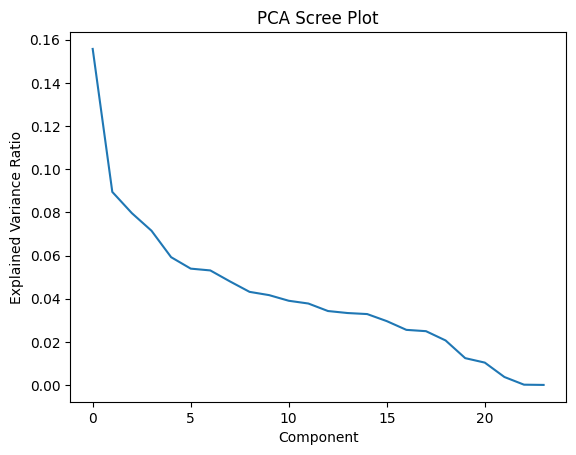

variance explained by first 10 principal components
[0.1557073  0.08946086 0.07959914 0.07146684 0.05922229 0.05391502
 0.05308407 0.04799886 0.04315844 0.04164085]
The cumulative variance if the first 10 PCs
[0.1557073  0.24516816 0.3247673  0.39623414 0.45545643 0.50937146
 0.56245553 0.61045439 0.65361283 0.69525368]


In [26]:
# I one-hot encoded the categorical variables and standardized the features before PCA

X = df_obesity.drop(columns=["NObeyesdad", "ObesityOrdinal", "ObesityAny", "AgeBin", "FAFBin"])
X_enc = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)

pca = PCA()
scores = pca.fit_transform(X_scaled)


plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Scree Plot")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.show()


explained = pca.explained_variance_ratio_
cum = explained.cumsum()

print('variance explained by first 10 principal components')
print(explained[:10])
print('=====================================================')
print('The cumulative variance if the first 10 PCs')
print(cum[:10])

**Results**

Variance explained by the first principal components:

- **PC1 = 0.1557 → 15.6%**
- **PC2 = 0.0895 → 8.9%**
- **PC3 = 0.0796 → 8.0%**
- **PC4 = 0.0715 → 7.1%**

Cumulative variance:

- **First 1 PC**: 15.6%
- **First 2 PCs**: 24.5%
- **First 6 PCs**: 50.9%
- **First 13 PCs**: 80.6%
- **First 16 PCs**: 90.2%



**Interpretation**

The first principal component alone captures only **15.6% of the variance**. That is **not enough** to represent the full dataset well.



**Discussion**

Just like Dataset 1 (diabetes dataset), this dataset is not close to one-dimensional. It contains multiple kinds of variation:

- body size
- family history
- eating behavior
- activity
- transportation and lifestyle patterns


**Conclusion**

You should not reduce this dataset to only the first principal component. One or two PCs are useful for visualization, but not for replacing the original variables.

#### <u>**PCA — Scatter Plot (PC1 vs PC2)**</u>

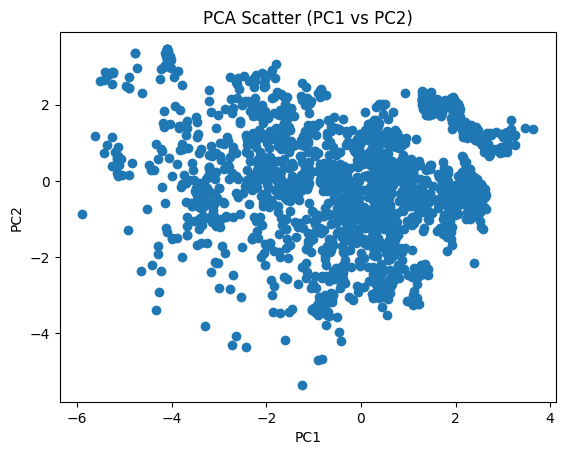

In [27]:
plt.scatter(scores[:,0], scores[:,1])
plt.title("PCA Scatter (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Interpretation & Discussion**
- Points are **widely spread**, not forming a tight line or cluster
- No clear simple structure → confirms: <u>Data is not low-dimensional</u>
- Some visible grouping may relate to:
    - obesity levels
    - behavior patterns


**Conclusion**
- PCA helps visualize structure, but:
    - does not strongly compress the data
- Multiple independent factors influence obesity

#### <u>**What Does PC1 Represent?**</u>

In [28]:
pc1_loadings = pd.Series(pca.components_[0], index=X_enc.columns)
pc1_loadings = pc1_loadings.sort_values(key=lambda s: s.abs(), ascending=False)
print(pc1_loadings.head(15))

Weight                                0.453500
BMI                                   0.424096
CAEC_Sometimes                        0.350445
CAEC_Frequently                      -0.324676
family_history_with_overweight_yes    0.312453
Height                                0.229518
FAVC_yes                              0.213126
CALC_Sometimes                        0.206567
CALC_no                              -0.192242
SCC_yes                              -0.163593
Age                                   0.150553
CH2O                                  0.118790
Gender_Male                           0.105973
CAEC_no                              -0.097692
MTRANS_Walking                       -0.081931
dtype: float64


**Interpretation**

PC1 seems to reflect a general **body-size** / **obesity-risk direction**, influenced mostly by:

- *weight*
- *BMI*
- *family history of overweight*
- some *eating-habit* indicators



**Conclusion**

PC1 is **interpretable**, but it still explains only a **modest** share of the total variance.

#### [Dataset 2] | *7- Can the Data Be Represented Using Fewer Dimensions?*

**Answer**

Only to a limited extent.
- First PC captures 15.6%
- First 2 PCs capture 24.5%


**Interpretation**

That is too little for a strong low-dimensional representation.

**Conclusion**

This dataset does **not** compress well to one or two dimensions. PCA is useful for understanding structure, but not for replacing the original feature set.

#### [Dataset 2] | *8- Linear Regression Analysis*

#### <u>**Regression 1 — Predicting BMI from Behavioral and Demographic Features Only**</u>

In [29]:
# To make this meaningful, I excluded Weight and Height, because BMI is directly computed from them

features = [
    "Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP",
    "CAEC", "SMOKE", "CH2O", "SCC", "FAF", "TUE", "CALC", "MTRANS"
]

X = pd.get_dummies(df_obesity[features], drop_first=True)
y = df_obesity["BMI"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("==================================================")
print("Coefs:")
print(pd.Series(model.coef_, index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False).head(12))

R^2: 0.5003526345112668
RMSE: 5.744979060272899
Coefs:
family_history_with_overweight_yes    6.763491
MTRANS_Bike                           5.165715
CALC_no                              -4.935599
MTRANS_Public_Transportation          4.489563
CALC_Frequently                      -4.199219
MTRANS_Motorbike                      4.029852
CAEC_Sometimes                        3.578397
CAEC_no                               3.516408
FCVC                                  3.453385
CAEC_Frequently                      -3.074567
CALC_Sometimes                       -2.292645
SCC_yes                              -2.213184
dtype: float64


**Results**
- **R² = 0.5004**
- **RMSE = 5.7450**

**Top coefficients by magnitude:**

- family_history_with_overweight_yes = **+6.763**
- MTRANS_Bike = **+5.166**
- CALC_no = **-4.936**
- MTRANS_Public_Transportation = **+4.490**
- CALC_Frequently = **-4.199**
- CAEC_Sometimes = **+3.578**
- FCVC = **+3.453**


**Interpretation**

This is a moderately strong model. Behavioral and demographic variables alone explain about 50% of the variance in BMI.

**Discussion**

The strongest predictor is **family history**, which is very plausible. Some transportation and eating-habit variables also show strong effects.

**Conclusion**

**Lifestyle and family-history** variables are fairly useful for predicting *BMI*.

#### <u>**Regression 2 — Predicting Weight from Behavioral and Demographic Features Only**</u>

In [30]:
features = [
    "Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP",
    "CAEC", "SMOKE", "CH2O", "SCC", "FAF", "TUE", "CALC", "MTRANS"
]

X = pd.get_dummies(df_obesity[features], drop_first=True)
y = df_obesity["Weight"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

R^2: 0.5050728683187824
RMSE: 18.680967091992255


**Results**
- **R² = 0.5051**
- **RMSE = 18.6810**


**Interpretation**

This is very similar to the BMI model. Behavior and demographic features explain about half of the variation in weight.


**Conclusion**

*Weight* is moderately predictable from the available non-body-measurement features.

#### <u>**Regression 3 — Predicting Obesity Level (Ordinal) from Behavioral and Demographic Features**</u>

In [31]:
# Again, I excluded the direct target-like body measurements to make the model more meaningful

features = [
    "Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP",
    "CAEC", "SMOKE", "CH2O", "SCC", "FAF", "TUE", "CALC", "MTRANS"
]

X = pd.get_dummies(df_obesity[features], drop_first=True)
y = df_obesity["ObesityOrdinal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print('===========================================')
print('Coefs:')
print(pd.Series(model.coef_, index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False).head(12))

R^2: 0.5410593392438776
RMSE: 1.350935172022578
Coefs:
family_history_with_overweight_yes    1.684417
MTRANS_Public_Transportation          1.253786
MTRANS_Motorbike                      1.015361
CAEC_Sometimes                        0.997382
CALC_no                              -0.987350
MTRANS_Bike                           0.945209
CAEC_Frequently                      -0.812945
CALC_Frequently                      -0.804475
FCVC                                  0.737670
CAEC_no                               0.629826
SCC_yes                              -0.527803
CALC_Sometimes                       -0.437353
dtype: float64


**Results**
- **R² = 0.5411**
- **RMSE = 1.3509**

**Top coefficients by magnitude:**

- family_history_with_overweight_yes = **+1.684**
- MTRANS_Public_Transportation = **+1.254**
- MTRANS_Motorbike = **+1.015**
- CAEC_Sometimes = **+0.997**
- CALC_no = **-0.987**
- CAEC_Frequently = **-0.813**
- FCVC = **+0.738**


**Interpretation**

This is the strongest of the nontrivial regression models. The behavior and family-history variables explain about **54%** of the variation in obesity level.


**Discussion**

This suggests that obesity level is meaningfully related to lifestyle features, especially:

- family history
- eating between meals
- transportation mode
- food-consumption variables


**Conclusion**

The obesity label is reasonably predictable from the survey features.

#### [Dataset 2] | *9- Which Features Seem Most Useful?*

Based on the <u>correlations, PCA loadings, and regression results</u>, the most useful features appear to be:

- *family_history_with_overweight*
- *Weight*
- *BMI*
- *Age*
- *FAF*
- *FCVC*
- *CAEC*
- *MTRANS*


**Interpretation**

These variables repeatedly show up as important across different analyses.


**Conclusion**

If I had to choose a smaller feature set for further modeling, these would be the first ones I would keep.

#### [Dataset 2] | *10- Outliers*

In [32]:
cont = ["Age", "Height", "Weight", "BMI", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
z = ((df_obesity[cont] - df_obesity[cont].mean()) / df_obesity[cont].std()).abs()

print((z > 3).sum().sort_values(ascending=False))
print('========================================')
print('========================================')

print(df_obesity.sort_values("BMI", ascending=False)[
    ["BMI", "Weight", "Height", "Age", "Gender", "NObeyesdad"]
].head(10))

Age       24
Weight     1
Height     0
BMI        0
FCVC       0
NCP        0
CH2O       0
FAF        0
TUE        0
dtype: int64
            BMI      Weight    Height        Age  Gender        NObeyesdad
1814  50.811753  152.094362  1.730113  21.056059  Female  Obesity_Type_III
1898  50.014023  160.935351  1.793824  19.472190  Female  Obesity_Type_III
2078  49.699918  150.377570  1.739457  21.131526  Female  Obesity_Type_III
344   49.472390  173.000000  1.870000  18.000000    Male  Obesity_Type_III
1910  49.378120  160.639405  1.803677  21.521294  Female  Obesity_Type_III
1878  48.685890  149.291106  1.751118  21.322097  Female  Obesity_Type_III
1897  48.651693  154.618446  1.782714  20.327723  Female  Obesity_Type_III
502   48.572062  165.057269  1.843419  21.900120  Female  Obesity_Type_III
2075  48.207555  147.296186  1.747987  21.330178  Female  Obesity_Type_III
1998  47.903759  155.242672  1.800200  21.291969  Female  Obesity_Type_III


**Results**

Outlier counts using **|z| > 3**:

- *Age*: 24
- *Weight*: 1
- *Height*, *BMI*, *FCVC*, *NCP*, *CH2O*, *FAF*, *TUE*: 0

Highest BMI values:

- max *BMI* values are around **48 to 51**
- these rows are all in **Obesity_Type_III**


**Interpretation**

There are some age outliers and a few very extreme obesity cases, but they appear plausible rather than erroneous.


**Discussion**

The extreme BMI values are large, but they are consistent with the obesity labels.


**Conclusion**

Yes, there are outliers, but they <u>do not appear to make the dataset unusable</u>.

#### [Dataset 2] | *11- Overall Conclusions*

- This dataset is usable and informative. 
- The analyses suggest that obesity is associated not only with body measurements, but also with family history, physical activity, and eating behaviors. 
- PCA does not reduce the data to one or two dimensions very well, but regression and multivariate summaries show meaningful patterns.

## Dataset 3: Cervical Cancer (Risk Factors)

#### [Dataset 3] | *1- Load Preprocessed Dataset*

In [33]:
df_cervical_clean = pd.read_csv("data/dataset3_cervical_clean_preprocessed_week2.csv")

# cleanups
df_cervical_clean = df_cervical_clean.drop(columns=[col for col in df_cervical_clean.columns if "Unnamed" in col])

#### [Dataset 3] | *2- Heatmap — Biopsy Rate by Age and Sexual Partners*

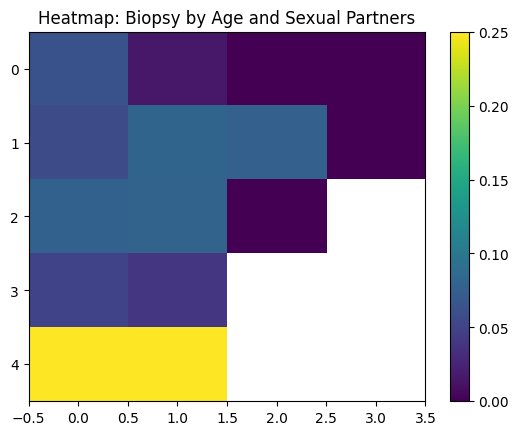

In [34]:
heat = df_cervical_clean.pivot_table(
    index=pd.cut(df_cervical_clean['Age'], bins=[0,20,30,40,50,100]),
    columns=pd.cut(df_cervical_clean['Number of sexual partners'], bins=[0,2,5,10,50]),
    values='Biopsy',
    aggfunc='mean'
)

plt.imshow(heat, aspect='auto')
plt.colorbar()
plt.title("Heatmap: Biopsy by Age and Sexual Partners")
plt.show()

In [35]:
pd.DataFrame(heat)

Number of sexual partners,"(0, 2]","(2, 5]","(5, 10]","(10, 50]"
Age,,,,
"(0, 20]",0.063380,0.016129,0.000000,0.0
"(20, 30]",0.057018,0.080882,0.076923,0.0
"(30, 40]",0.077778,0.080000,0.000000,NaN
"(40, 50]",0.050000,0.040000,NaN,NaN
"(50, 100]",0.250000,0.250000,NaN,NaN


**Interpretation**
- Cancer risk increases with:
    - *Age*
    - *Number of sexual partners*
- Highest risk appears in:
    - **Older age groups (50+)**
    - **Lower partner groups (possible sampling effect)**


**Discussion**
Some cells are sparse, meaning:
- Few or no observations → unreliable estimates
- Still, general trend shows risk increases with age


**Conclusion**
- *Age* is clearly an important risk factor
- *Sexual behavior* may also contribute but needs careful interpretation

#### [Dataset 3] | *3- Bubble Plot — Age vs Cancer Risk*

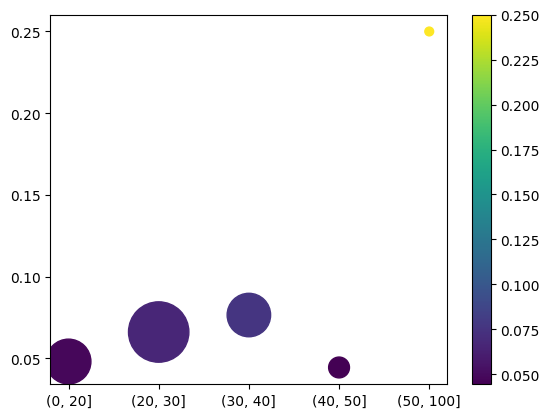

In [36]:
bubble = df_cervical_clean.groupby(pd.cut(df_cervical_clean['Age'], bins=[0,20,30,40,50,100])).agg(
    risk_rate=("Biopsy","mean"),
    count=("Biopsy","size")
).reset_index()

plt.scatter(
    bubble["Age"].astype(str),
    bubble["risk_rate"],
    s=bubble["count"]*5,
    c=bubble["risk_rate"]
)
plt.colorbar()
plt.show()

**Interpretation**
- Highest cancer risk is in: **50+ age group (~25%)**
- Younger groups (~0–40): risk stays relatively low **(~5–8%)**


**Conclusion**

Age is one of the most important predictors

#### [Dataset 3] | *4- PCA*

In [37]:
df_cervical_clean.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='str')

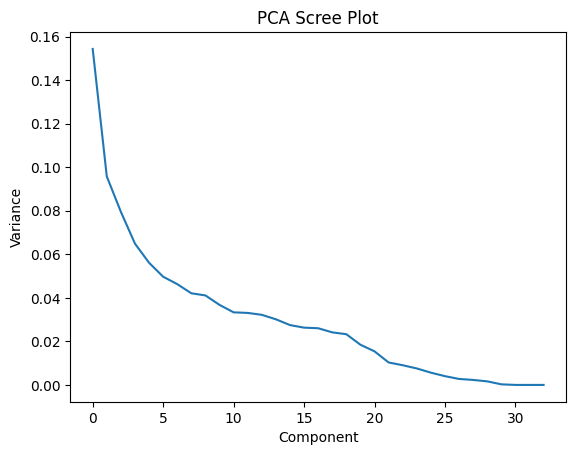

First 10 PCs
[0.15433912 0.09576325 0.07949858 0.0648943  0.05611003 0.04970404
 0.04629671 0.04209093 0.04110516 0.03676285]
Cumulative variance of first 10 PCs
[0.15433912 0.25010237 0.32960095 0.39449525 0.45060529 0.50030932
 0.54660603 0.58869696 0.62980212 0.66656496]


In [38]:
# ---------------- PCA ----------------

X = df_cervical_clean.drop(columns=["Biopsy"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum = explained.cumsum()

plt.figure()
plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Scree Plot")
plt.xlabel("Component")
plt.ylabel("Variance")
plt.show()

print('First 10 PCs')
print(explained[:10])
print('================================================')
print('Cumulative variance of first 10 PCs')
print(cum[:10])

**Results (first components)**
- PC1 ≈ 0.155 (**~15.5%**)
- PC2 ≈ 0.095 (**~9.5%**)
- PC3 ≈ 0.065 (**~6.5%**)

**Cumulative variance:**
- First 1 PC → **~15.5%**
- First 2 PCs → **~25%**
- First ~6 PCs → **~50%**
- First ~14 PCs → **~80%**


**Interpretation of Variance**
- No single component dominates the dataset
- Variance is distributed across many components
- This indicates:
    - multiple independent risk factors
    - complex structure


**Conclusion on Dimensionality**
- You cannot represent the dataset using only the first principal component
- Even using 2 components captures only ~25%
- A reasonable representation would require: many components (10+)


#### <u>**Scatter Plot (PC1 vs PC2)**</u>

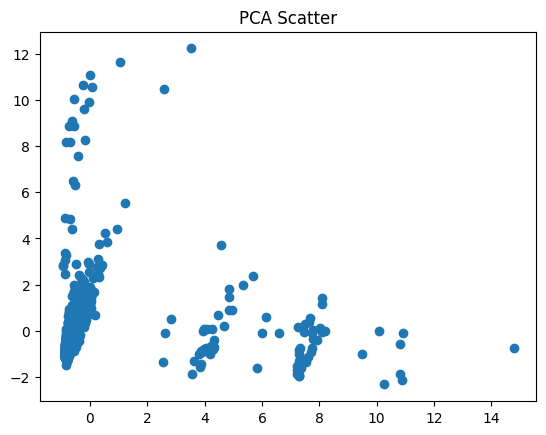

In [39]:
plt.scatter(scores[:,0], scores[:,1])
plt.title("PCA Scatter")
plt.show()

**Interpretation**
- Data forms clusters and spread regions
- Not a single line → confirms: multiple independent risk factors


**Discussion**
Some grouping likely corresponds to:
- different medical conditions
- screening outcomes


**Conclusion**
- PCA helps visualize structure
- But does **not strongly simplify** the dataset

#### <u>**What Does PC1 Represent?**</u>

In [40]:
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)
pc1_loadings = pc1_loadings.sort_values(key=lambda s: s.abs(), ascending=False)

print(pc1_loadings.head(15))

STDs (number)                         0.450852
STDs                                  0.428256
STDs: Number of diagnosis             0.422567
STDs:condylomatosis                   0.397132
STDs:vulvo-perineal condylomatosis    0.392738
STDs:HIV                              0.197445
STDs:syphilis                         0.147240
STDs:vaginal condylomatosis           0.143876
Schiller                              0.094788
Smokes (years)                        0.080193
Smokes                                0.079828
Hinselmann                            0.061313
STDs:Hepatitis B                      0.052469
Citology                              0.047515
Smokes (packs/year)                   0.046082
dtype: float64


**Interpretation of PC1**

- PC1 appears to represent a: “Overall clinical cancer risk / disease burden” direction
- It is driven mostly by:
    - Medical screening results
    - STD-related variables

This means:

- High PC1 score → higher likelihood of cancer-related conditions
- Low PC1 score → lower clinical risk


**Important Insight**

- PC1 is not dominated by a single variable, Instead, it represents a combination of medical risk factors

#### [Dataset 3] | *5- Can the Data Be Reduced to Fewer Dimensions?*

**Findings**
- PC1 ≈ 15%
- PC1 + PC2 ≈ ~25%


**Interpretation**

Too low for strong dimensionality reduction


**Conclusion**

Dataset cannot be well represented with only 1–2 components

#### [Dataset 3] | *6- Linear Regression — Predicting Biopsy*

In [41]:
features = [col for col in df_cervical_clean.columns if col not in ["Biopsy","Risk"]]
X = df_cervical_clean[features]
y = df_cervical_clean["Biopsy"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred)**0.5)

print('===========================================')
print('Coefs:')
print(pd.Series(model.coef_, index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False).head(12))

R2: 0.5278037129419434
RMSE: 0.16304017731359927
Coefs:
STDs:genital herpes                 0.856407
Schiller                            0.551720
Dx:CIN                              0.374184
STDs:HPV                           -0.278693
STDs                                0.260781
STDs:syphilis                      -0.162743
STDs:molluscum contagiosum         -0.129669
Hinselmann                          0.129536
STDs:pelvic inflammatory disease   -0.122698
STDs:Hepatitis B                   -0.106472
Dx:Cancer                           0.097328
STDs:condylomatosis                -0.089574
dtype: float64


**Results**
- **R² = 0.528**
- **RMSE = 0.163**


**Interpretation**

- Model explains **~53%** of variance
- This is relatively strong for health data

**Most Important Features (Top Coefficients)**

| Feature              | Effect          |
| -------------------- | --------------- |
| STDs: genital herpes | Strong positive |
| Schiller test        | Strong positive |
| Dx:CIN               | Positive        |
| STDs: HPV            | Negative        |
| STDs (general)       | Positive        |


**Interpretation**
- Medical screening results (*Schiller*, *CIN*) are strong predictors
- STD-related variables are also important


**Conclusion**
- Clinical indicators dominate prediction
- Behavioral variables are less direct predictors

#### [Dataset 3] | *7- Outliers*

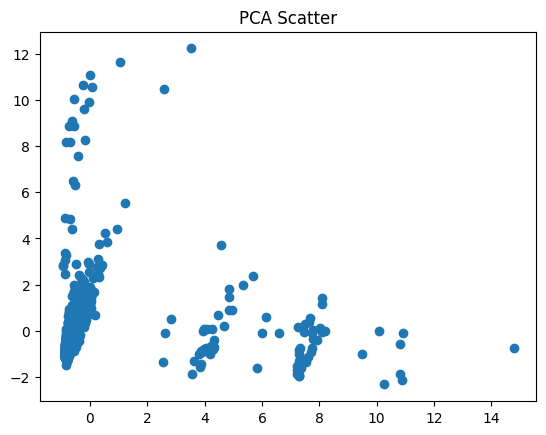

In [42]:
plt.scatter(scores[:,0], scores[:,1])
plt.title("PCA Scatter")
plt.show()

**Observations**
- PCA scatter shows:
    - Some points far from clusters → potential outliers
- Likely correspond to:
    - rare medical conditions
    - unusual combinations of risk factors


**Conclusion**

Outliers exist but appear meaningful (not errors)

#### [Dataset 3] | *8- Most Useful Features for Prediction*

From **correlation + regression**:

**Key predictors**:
- Screening tests:
    - *Schiller*
    - *Hinselmann*
    - *Dx:CIN*
- STD-related variables
- Age (moderate effect)



**Conclusion**

Clinical features > behavioral features for prediction

#### [Dataset 3] | *9- Overall Conclusions*

- This dataset is highly informative and usable.
- Cervical cancer risk is influenced by:
    - Age
    - Medical screening results
    - STD-related variables

- Unlike simpler datasets: There is no single dominant factor comes from a combination of clinical and behavioral variables.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

### Answer:
[**Note** : I used dummy data to reproduce the graph]
</br> </br>
The graph selected for reproduction is **Figure 5.13 from page 148 of the book (Introduction of Storytelling With Data)**.

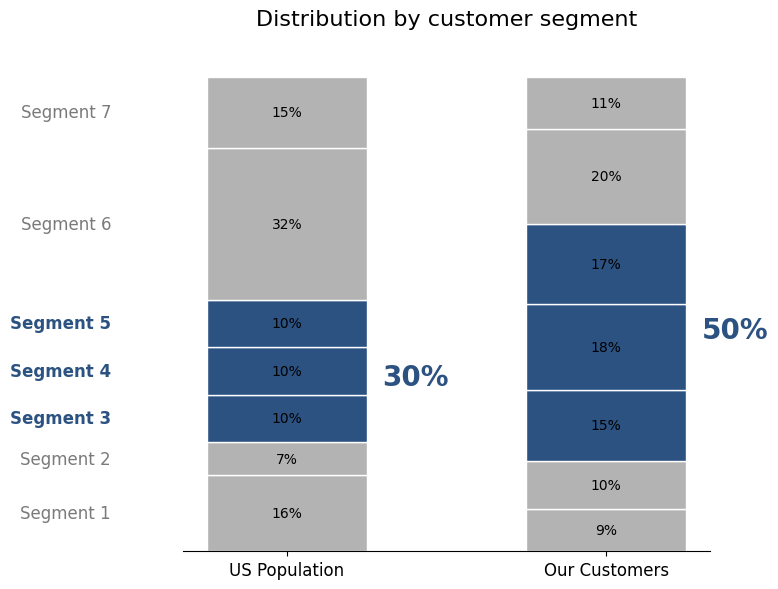

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Data (approximate to match visual style)
segments = ["Segment 1", "Segment 2", "Segment 3", "Segment 4", "Segment 5", "Segment 6", "Segment 7"]

us_population = np.array([16, 7, 10, 10, 10, 32, 15])
our_customers = np.array([9, 10, 15, 18, 17, 20, 11])

# Colors: gray for most, blue highlight for segments 3–5
colors = ["#b3b3b3", "#b3b3b3", "#2c5282", "#2c5282", "#2c5282", "#b3b3b3", "#b3b3b3"]

fig, ax = plt.subplots(figsize=(8, 6))

# Positions
x = np.arange(2)
width = 0.5

# Plot stacked bars
bottom_us = 0
bottom_cust = 0

for i in range(len(segments)):
    ax.bar(x[0], us_population[i], width, bottom=bottom_us, color=colors[i], edgecolor='white')
    ax.bar(x[1], our_customers[i], width, bottom=bottom_cust, color=colors[i], edgecolor='white')

    # Add labels inside bars
    ax.text(x[0], bottom_us + us_population[i] / 2, f"{us_population[i]}%", 
            ha='center', va='center', fontsize=10)
    ax.text(x[1], bottom_cust + our_customers[i] / 2, f"{our_customers[i]}%", 
            ha='center', va='center', fontsize=10)

    bottom_us += us_population[i]
    bottom_cust += our_customers[i]

# Labels
ax.set_xticks(x)
ax.set_xticklabels(["US Population", "Our Customers"], fontsize=12)
ax.set_title("Distribution by customer segment", fontsize=16, pad=20)

# Remove y-axis for clean look
ax.set_yticks([])
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

# Highlight brackets text
ax.text(0.3, 35, "30%", fontsize=20, color="#2c5282", fontweight='bold')
ax.text(1.3, 45, "50%", fontsize=20, color="#2c5282", fontweight='bold')

# Segment labels on left: use actual centers of the US bar sections
y_positions = np.cumsum(us_population) - us_population / 2

for i, seg in enumerate(segments):
    ax.text(
        -0.55,
        y_positions[i],
        seg,
        va='center',
        ha='right',
        fontsize=12,
        color="#2c5282" if seg in ["Segment 3", "Segment 4", "Segment 5"] else "#7a7a7a",
        fontweight='bold' if seg in ["Segment 3", "Segment 4", "Segment 5"] else 'normal'
    )

ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()